# 🧠 From Correlation to Causation: Heart Disease Analysis
This notebook explores causal relationships between clinical variables and heart disease risk using DAGs, regression, and intervention-based reasoning.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

C:\Users\ankit soni\AppData\Local\Temp\ipykernel_15944\1262949492.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')[['oldpeak' , 'target']].corr()
C:\Users\ankit soni\AppData\Local\Temp\ipykernel_15944\1262949492.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')['target'].mean()


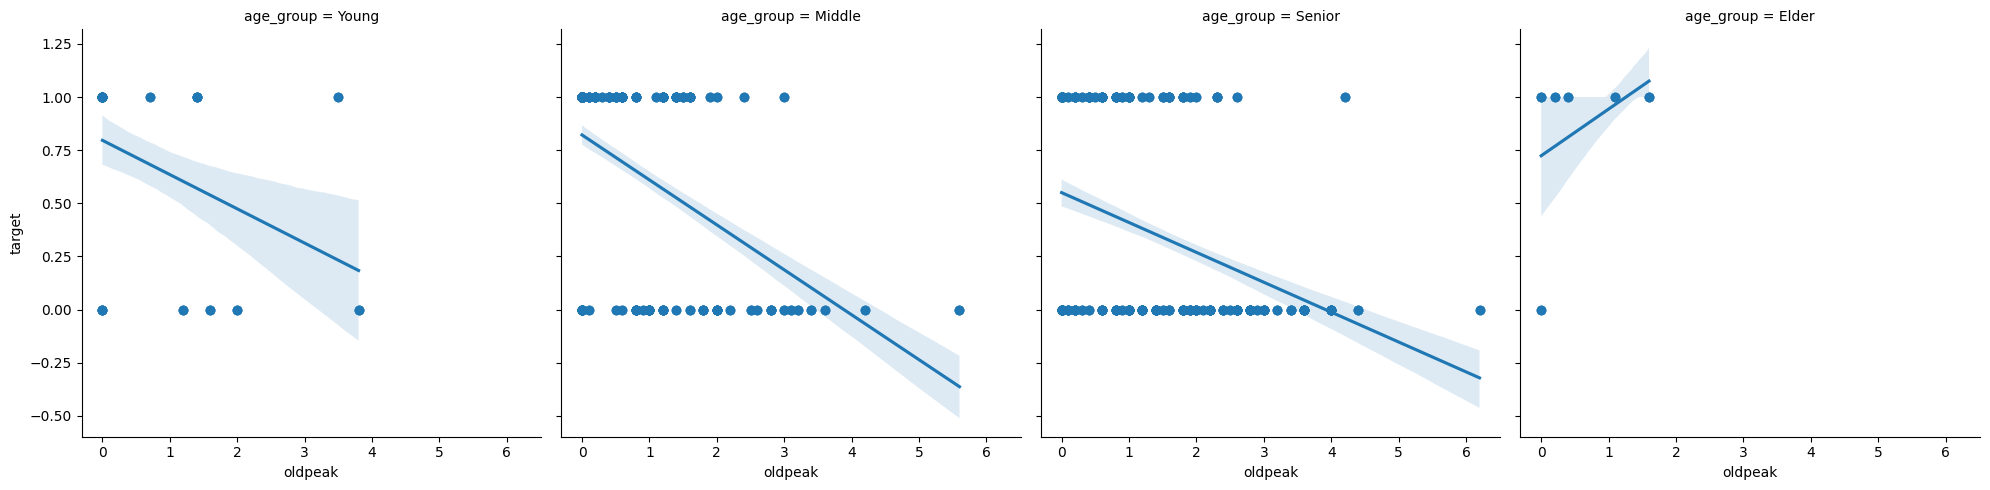

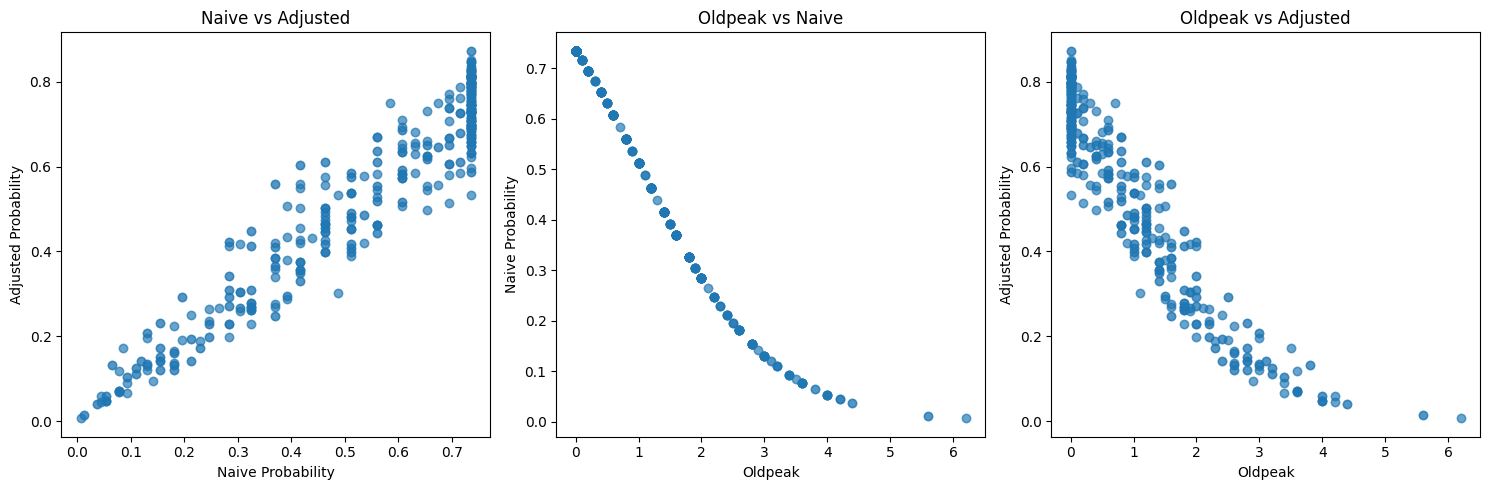

[[0.8773392  0.8636176  0.84862586 ... 0.02281423 0.02025093 0.01797033]
 [0.87316129 0.8590754  0.84370522 ... 0.02221121 0.01971876 0.017501  ]
 [0.86886235 0.85440742 0.83865503 ... 0.02162377 0.0192003  0.01704371]
 ...
 [0.54213235 0.51449319 0.4867651  ... 0.00639835 0.00573032 0.00513168]
 [0.53261939 0.50498816 0.47732642 ... 0.00622647 0.00557756 0.00499595]
 [0.52308266 0.49547952 0.46790391 ... 0.00605917 0.00542886 0.00486379]]


C:\Users\ankit soni\AppData\Local\Temp\ipykernel_15944\1262949492.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')['target'].mean()
C:\Users\ankit soni\AppData\Local\Temp\ipykernel_15944\1262949492.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')[['target','oldpeak']].corr()


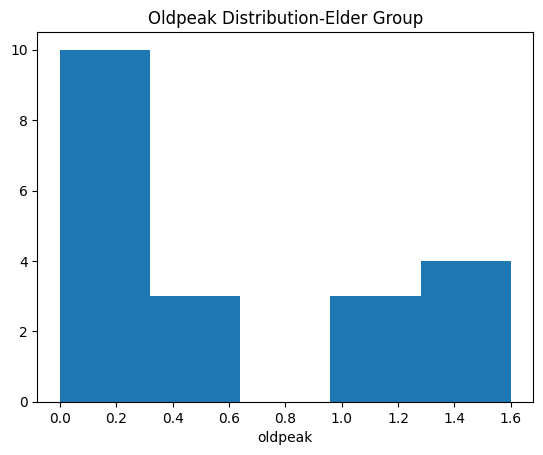

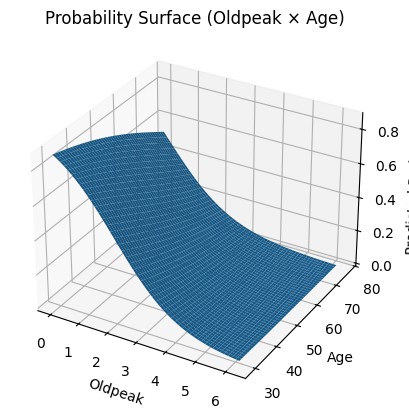

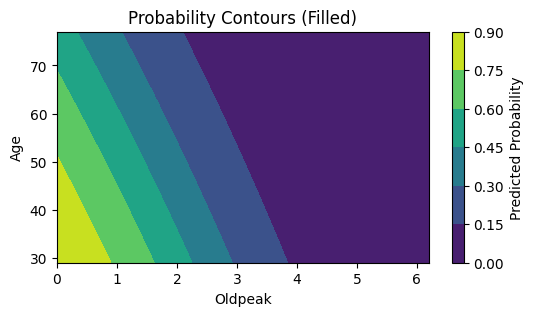

Naive: [[-0.97176259]]
Adjusted: [[-0.91552175 -0.03745005]]
Collider: [[-7.1354655  -0.02353688  6.91581296]]


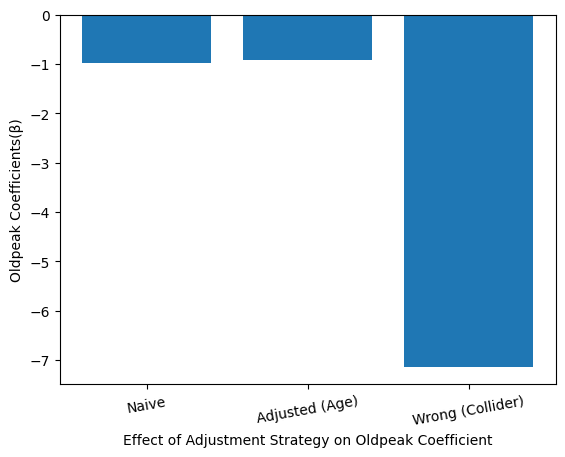

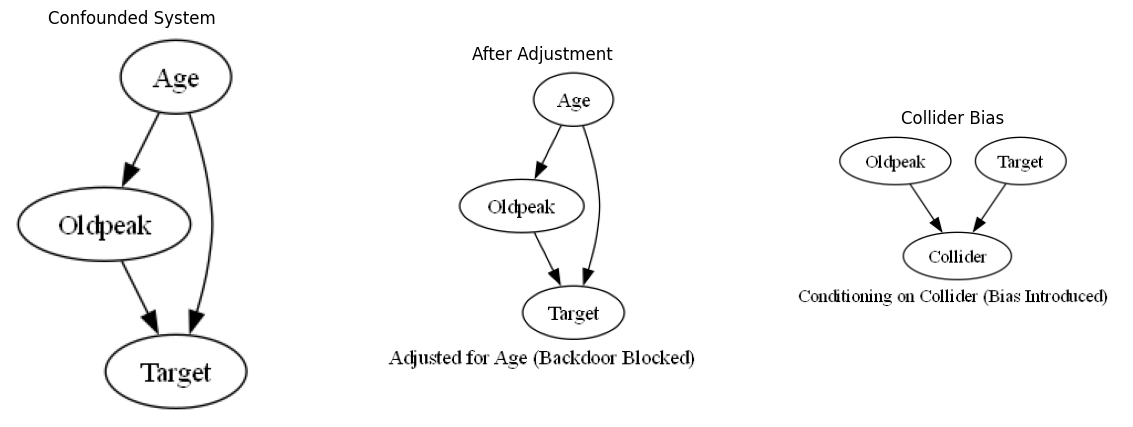

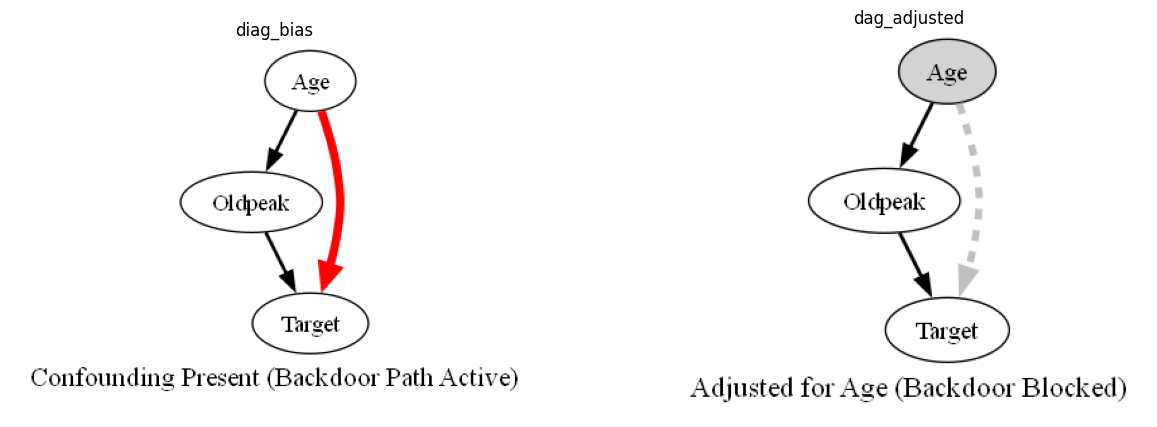

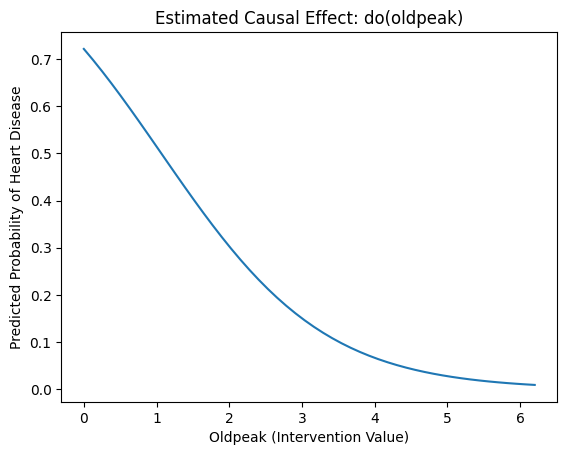

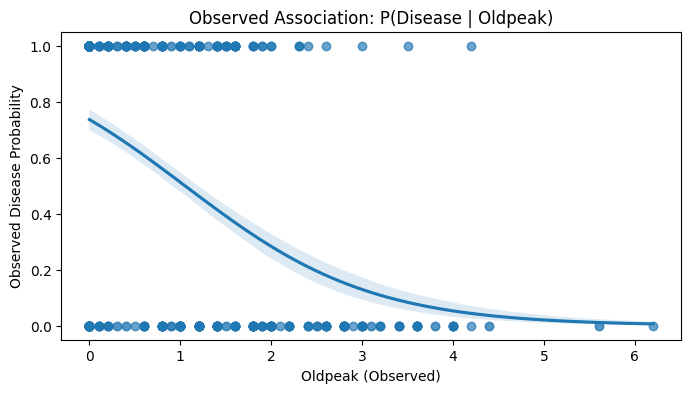

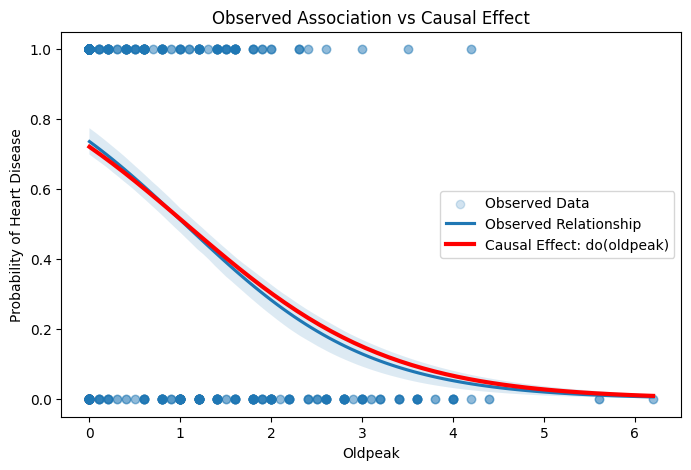

Average Treatment Effect: -0.17752888440398784


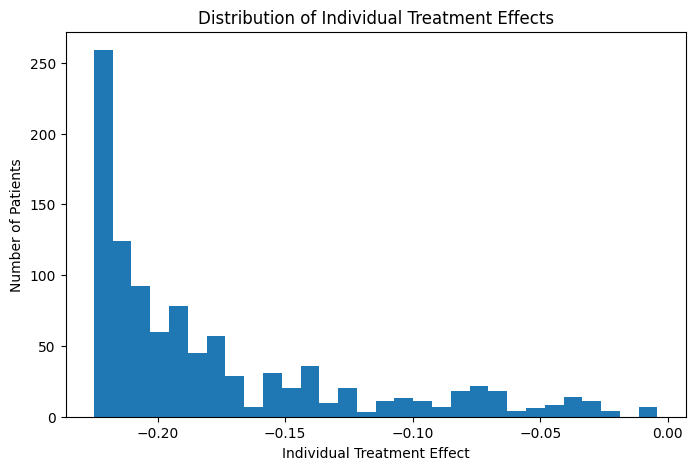

C:\Users\ankit soni\AppData\Local\Temp\ipykernel_15944\1262949492.py:310: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = data.pivot_table(


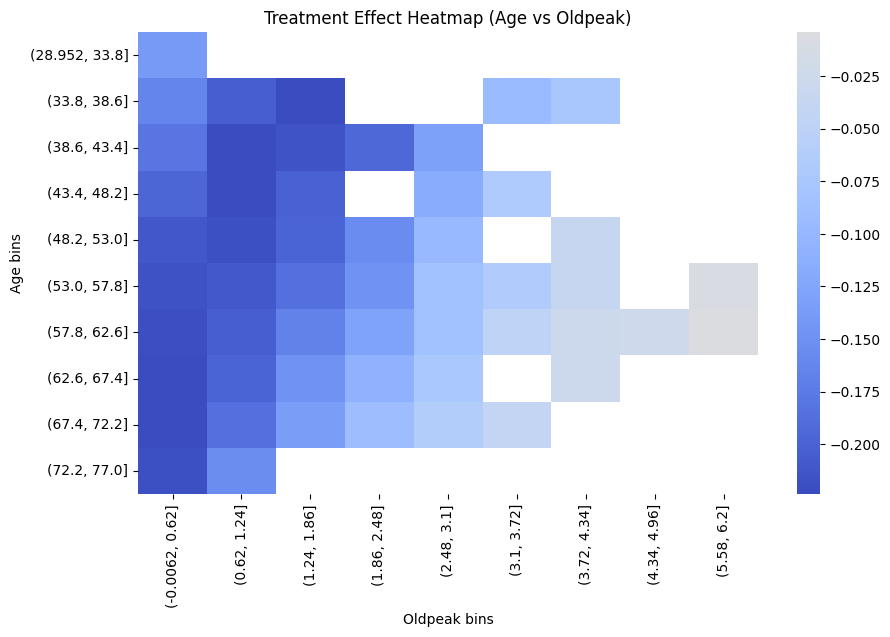

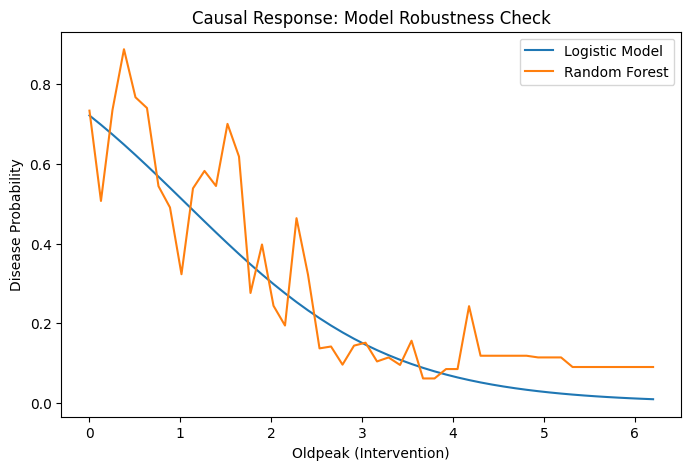

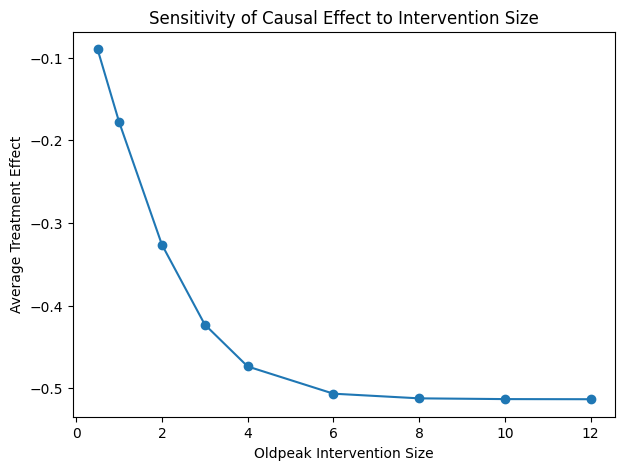

Observed probability: [0.41790271]
Counterfactual probability: [0.12139048]
Individual Treatment Effect: [-0.29651223]


C:\Users\ankit soni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\ankit soni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\ankit soni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\ankit soni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\ankit soni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X 

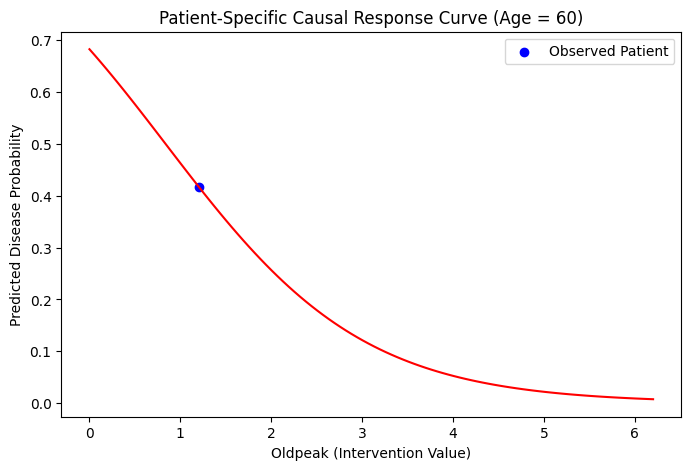

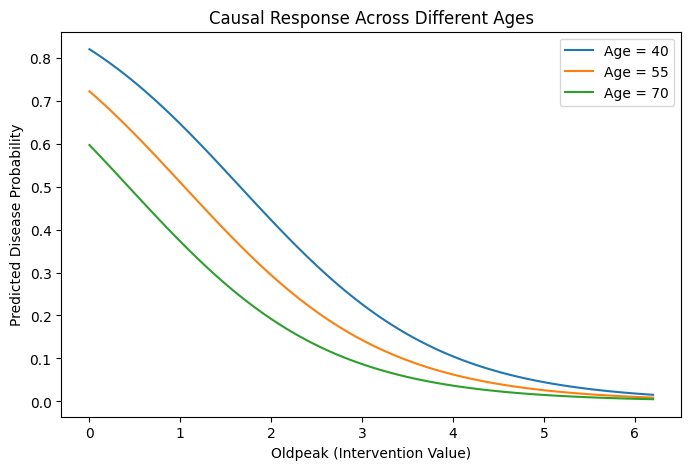

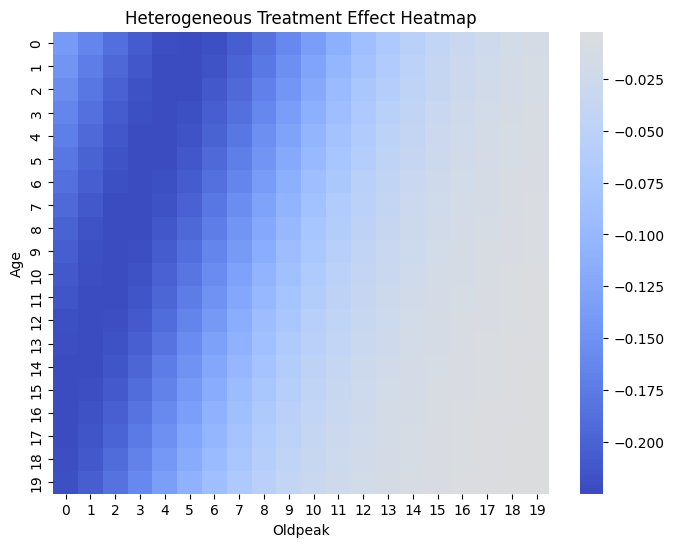

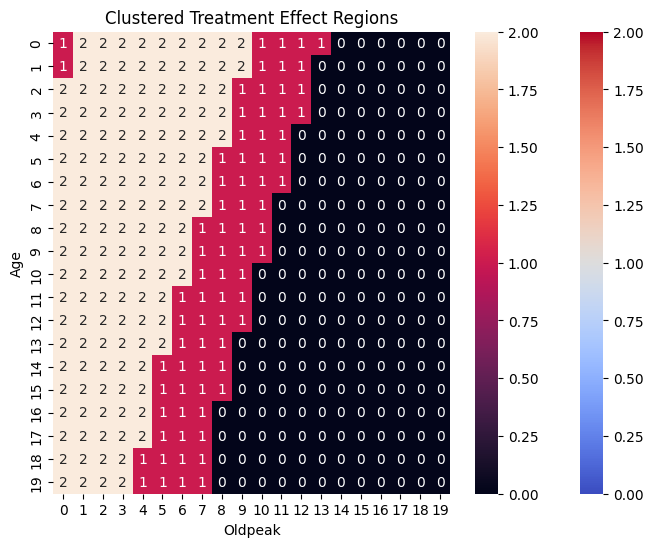

In [ ]:
### 📊 Data Loading & Overview
## We begin by loading the dataset and understanding its structure.


import pandas as pd
data = pd.read_csv(r"C:\Users\ankit soni\Downloads\HeartDiseaseTrain-Test.csv")
data.info()
data.shape
data.describe(include = "all")
data.head()
data.select_dtypes(include = "number").corr()
data['age_group'] = pd.cut(data['age'] , bins = [0, 40 , 55 , 70 , 90] , labels = ['Young' , 'Middle' , 'Senior' , 'Elder'])
print(data['age_group'])
data.groupby('age_group')[['oldpeak' , 'target']].corr()
data['age_group'].value_counts()
data.groupby('age_group')['target'].mean()
data.head()



### 🔍 Exploratory Data Analysis
## We explore distributions and relationships between variables.


import seaborn as sns 
import matplotlib.pyplot as plt
sns.lmplot(data=data, x = 'oldpeak' , y = 'target', col = 'age_group')
plt.show()

## 🤖 Logistic Regression Modeling
## We build both naive and adjusted models to understand confounding.

X = data[['oldpeak' , 'age']]
y = data['target']
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X,y)
model.coef_
model.intercept_
import numpy as np
np.exp(model.coef_)
model_naive = LogisticRegression()
model_naive.fit(data[['oldpeak']] , data['target'])
model_naive.coef_
data['prob_naive'] = model_naive.predict_proba(data[['oldpeak']])[:,1]
data['prob_adjusted'] = model.predict_proba(data[['oldpeak' , 'age']])[:,1]
data[['oldpeak', 'age', 'prob_naive', 'prob_adjusted']].head()
data[data['oldpeak']>2]['target'].mean()
figs,axes = plt.subplots(nrows=1 , ncols=3 , figsize=(15,5))
axes[0].scatter(data['prob_naive'] , data['prob_adjusted'],alpha=0.3)
axes[0].set_xlabel("Naive Probability")
axes[0].set_ylabel("Adjusted Probability")
axes[0].set_title("Naive vs Adjusted")
axes[1].scatter(data['oldpeak'], data['prob_naive'],alpha=0.3)
axes[1].set_xlabel("Oldpeak")
axes[1].set_ylabel("Naive Probability")
axes[1].set_title("Oldpeak vs Naive")
axes[2].scatter(data['oldpeak'], data['prob_adjusted'],alpha=0.3)
axes[2].set_xlabel("Oldpeak")
axes[2].set_ylabel("Adjusted Probability")
axes[2].set_title("Oldpeak vs Adjusted")
plt.tight_layout()
plt.show()



# ⚠️ Simpson’s Paradox Exploration
## We analyze how subgroup analysis changes observed relationships.



data.groupby('age_group')['target'].mean()
data.groupby('age_group')[['target','oldpeak']].corr()
data['age_group'].value_counts()
data[data['age_group']=='Elder']['target'].value_counts()
plt.hist(data[data['age_group']=='Elder']['oldpeak'],bins=5)
plt.title("Oldpeak Distribution-Elder Group")
plt.xlabel("oldpeak")
plt.show
data['interaction'] = data['oldpeak']*data['age']
model_interact = LogisticRegression(max_iter =1000)
model_interact.fit(data[['oldpeak' , 'age' , 'interaction']] , data['target'])
model_interact.coef_
beta = model_interact.coef_[0]
intercept = model_interact.intercept_[0]
beta , intercept
oldpeak_range = np.linspace(data['oldpeak'].min() , data['oldpeak'].max() , 50)
age_range = np.linspace(data['age'].min() , data['age'].max() , 50)
O,A = np.meshgrid(oldpeak_range , age_range)
b_oldpeak , b_age, b_inter = beta 
logit = intercept + b_oldpeak*O + b_age*A + b_inter*(O*A)
logit
P = 1/(1+np.exp(-logit))
print(P)
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.plot_surface(O,A,P)
ax.set_xlabel("Oldpeak")
ax.set_ylabel("Age")
ax.set_zlabel("Predicted Probability")
ax.set_title("Probability Surface (Oldpeak × Age)")
plt.show()
plt.figure(figsize=(6,3))
plt.contourf(O,A,P)
plt.xlabel("Oldpeak")
plt.ylabel("Age")
plt.title("Probability Contours (Filled)")
plt.colorbar(label="Predicted Probability")
plt.show()
data['collider'] = data['oldpeak'] + data['target']
from sklearn.linear_model import LogisticRegression
#Naive
model_naive = LogisticRegression(max_iter=1000)
model_naive.fit(data[['oldpeak']] , data['target'])
#Proper Adjustment
model_adjusted = LogisticRegression(max_iter=1000)
model_adjusted.fit(data[['oldpeak' , 'age']],data['target'])
#Wrong Adjustemnt 
model_collider = LogisticRegression(max_iter=1000)
model_collider.fit(data[['oldpeak' , 'age' , 'collider']] , data['target'])
print("Naive:", model_naive.coef_)
print("Adjusted:", model_adjusted.coef_)
print("Collider:", model_collider.coef_)
import matplotlib.pyplot as plt 
import numpy as np
# Extract coefficients
coef_naive = model_naive.coef_[0][0]
coef_adjusted = model_adjusted.coef_[0][0]
coef_collider = model_collider.coef_[0][0]
models = ['Naive', 'Adjusted (Age)', 'Wrong (Collider)']
coefficients = [coef_naive, coef_adjusted, coef_collider]
plt.figure()
plt.bar(models,coefficients)
plt.ylabel("Oldpeak Coefficients(β)")
plt.xlabel("Effect of Adjustment Strategy on Oldpeak Coefficient")
plt.xticks(rotation=10)
plt.show()
from graphviz import Digraph
dag1 = Digraph()
dag1.edge("Age", "Oldpeak")
dag1.edge("Age", "Target")
dag1.edge("Oldpeak", "Target")

dag1
dag2 = Digraph()

dag2.edge("Age", "Oldpeak")
dag2.edge("Age", "Target")
dag2.edge("Oldpeak", "Target")

dag2.attr(label="Adjusted for Age (Backdoor Blocked)")

dag2

dag3 = Digraph()

dag3.edge("Oldpeak", "Collider")
dag3.edge("Target", "Collider")

dag3.attr(label="Conditioning on Collider (Bias Introduced)")

dag3
import matplotlib.image as mpimg
dag1.render("dag1", format="png", cleanup=True)
dag2.render("dag2", format="png", cleanup=True)
dag3.render("dag3", format="png", cleanup=True)
img1 = mpimg.imread("dag1.png")
img2 = mpimg.imread("dag2.png")
img3 = mpimg.imread("dag3.png")

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(img1)
axes[0].set_title("Confounded System")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("After Adjustment")
axes[1].axis("off")

axes[2].imshow(img3)
axes[2].set_title("Collider Bias")
axes[2].axis("off")

plt.show()

dag_bias = Digraph()

# Nodes
dag_bias.node("Age")
dag_bias.node("Oldpeak")
dag_bias.node("Target")

# Causal paths (normal)
dag_bias.edge("Age", "Oldpeak" ,color="black", penwidth="2")
dag_bias.edge("Oldpeak", "Target", color="black", penwidth="2")

# Backdoor path (highlighted)
dag_bias.edge("Age", "Target", color="red", penwidth="5")

dag_bias.attr(label="Confounding Present (Backdoor Path Active)" , fontsize = "16")

dag_bias
dag_adjusted = Digraph()

dag_adjusted.node("Age", style="filled", fillcolor="lightgrey")
dag_adjusted.node("Oldpeak")
dag_adjusted.node("Target")

dag_adjusted.edge("Age", "Oldpeak")
dag_adjusted.edge("Oldpeak", "Target")

# Backdoor path now greyed
dag_adjusted.edge("Age", "Target", color="grey", style="dashed")

dag_adjusted.attr(label="Adjusted for Age (Backdoor Blocked)")

dag_adjusted
dag_adjusted = Digraph()

dag_adjusted.node("Age", style="filled", fillcolor="lightgrey")
dag_adjusted.node("Oldpeak")
dag_adjusted.node("Target")

dag_adjusted.edge("Age", "Oldpeak",  penwidth="2")
dag_adjusted.edge("Oldpeak", "Target",  penwidth="2")

# Backdoor path now greyed
dag_adjusted.edge("Age", "Target", color="grey", style="dashed", penwidth="4")

dag_adjusted.attr(label="Adjusted for Age (Backdoor Blocked)", fontsize = "16")

dag_adjusted
dag_bias.render("dag_bias", format="png", cleanup=True)
dag_adjusted.render("dag_adjusted", format="png", cleanup=True)
import matplotlib.image as mpimg

img1 = mpimg.imread("dag_bias.png")
img2 = mpimg.imread("dag_adjusted.png")
fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].imshow(img1)
axes[0].set_title("diag_bias")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("dag_adjusted")
axes[1].axis("off")
plt.show()

# 📈 Model Predictions & Visualization
## We compare naive vs adjusted probabilities.



oldpeak_values = np.linspace(data['oldpeak'].min(),data['oldpeak'].max(), 50)
intervention_results = []
for i in oldpeak_values:
    data_copy = data.copy()
    data_copy["oldpeak"] = i
    X_intervene = data_copy[["oldpeak", "age"]]
    probs = model_adjusted.predict_proba(X_intervene)[:,1]
    intervention_results.append(probs.mean())
plt.figure()

plt.plot(oldpeak_values, intervention_results)

plt.xlabel("Oldpeak (Intervention Value)")
plt.ylabel("Predicted Probability of Heart Disease")

plt.title("Estimated Causal Effect: do(oldpeak)")

plt.show()
import seaborn as sns

plt.figure(figsize = (8,4))

sns.regplot(
    x=data["oldpeak"],
    y=data["target"],
    logistic=True,
    scatter_kws={"alpha":0.3}
)

plt.xlabel("Oldpeak (Observed)")
plt.ylabel("Observed Disease Probability")
plt.title("Observed Association: P(Disease | Oldpeak)")

plt.show()
plt.figure(figsize=(8,5))
plt.scatter(data["oldpeak"], data["target"], alpha=0.2, label="Observed Data")
sns.regplot(
    x=data["oldpeak"],
    y=data["target"],
    logistic=True,
    scatter=False,
    label="Observed Relationship"
)
plt.plot(
    oldpeak_values,
    intervention_results,
    color="red",
    linewidth=3,
    label="Causal Effect: do(oldpeak)"
)
plt.xlabel("Oldpeak")
plt.ylabel("Probability of Heart Disease")

plt.title("Observed Association vs Causal Effect")

plt.legend()

plt.show()



# ⚙️ Causal Analysis (do-Operator)
## We simulate interventions to estimate causal effects.



delta = 1

data_plus = data.copy()
data_plus["oldpeak"] = data_plus["oldpeak"] + delta

X_original = data[["oldpeak","age"]]
X_plus = data_plus[["oldpeak","age"]]

p_original = model_adjusted.predict_proba(X_original)[:,1]
p_plus = model_adjusted.predict_proba(X_plus)[:,1]

ATE = (p_plus - p_original).mean()

print("Average Treatment Effect:", ATE)
ITE = p_plus - p_original
plt.figure(figsize = (8,5))
plt.hist(ITE , bins=30)
plt.xlabel("Individual Treatment Effect")
plt.ylabel("Number of Patients")

plt.title("Distribution of Individual Treatment Effects")

plt.show()
import pandas as pd
data["ITE"] = ITE
heatmap_data = data.pivot_table(
    values="ITE",
    index=pd.cut(data["age"], bins=10),
    columns=pd.cut(data["oldpeak"], bins=10),
    aggfunc="mean"
)
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0
)
plt.title("Treatment Effect Heatmap (Age vs Oldpeak)")
plt.xlabel("Oldpeak bins")
plt.ylabel("Age bins")

plt.show()

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(data[["oldpeak","age"]], data["target"])
rf_results = []

for val in oldpeak_values:
    
    data_copy = data.copy()
    data_copy["oldpeak"] = val
    
    probs = rf_model.predict_proba(data_copy[["oldpeak","age"]])[:,1]
    
    rf_results.append(probs.mean())
plt.figure(figsize=(8,5))

plt.plot(oldpeak_values, intervention_results, label="Logistic Model")
plt.plot(oldpeak_values, rf_results, label="Random Forest")

plt.xlabel("Oldpeak (Intervention)")
plt.ylabel("Disease Probability")

plt.title("Causal Response: Model Robustness Check")

plt.legend()
plt.show()


effects =[]
deltas = [0.5 , 1,2,3,4,6,8,10,12]
for delta in deltas:
    data_plus = data.copy()
    data_plus["oldpeak"] = data_plus["oldpeak"] + delta

    p_original = model_adjusted.predict_proba(data[["oldpeak", "age"]])[:,1]
    p_plus = model_adjusted.predict_proba(data_plus[["oldpeak" , "age"]])[:, 1]

    effects.append((p_plus - p_original).mean())

plt.figure(figsize=(7,5))

plt.plot(deltas, effects, marker="o")

plt.xlabel("Oldpeak Intervention Size")
plt.ylabel("Average Treatment Effect")

plt.title("Sensitivity of Causal Effect to Intervention Size")

plt.show()

data["interaction"]= data["oldpeak"] * data["age"]
from sklearn.linear_model import LogisticRegression
interaction_model = LogisticRegression(max_iter=1000)
interaction_model.fit(data[["oldpeak" , "age" , "interaction"]] , data["target"] )
interaction_model.coef_

patient_age =60
oldpeak_original = 1.2 
oldpeak_new = 3
import numpy as np
observed = np.array([[oldpeak_original , patient_age]])
counterfactual = np.array([[oldpeak_new , patient_age]])
p_observed = model_adjusted.predict_proba(observed)[:,1]
p_counterfactual = model_adjusted.predict_proba(counterfactual)[:,1]
ITE = p_counterfactual - p_observed
print("Observed probability:", p_observed)
print("Counterfactual probability:", p_counterfactual)
print("Individual Treatment Effect:", ITE)
oldpeak_range = np.linspace(data['oldpeak'].min() , data['oldpeak'].max() , 100)
patient_age = 60
probabilities = []
for val in  oldpeak_range:
    patient = np.array([[val, patient_age]])
    prob = model_adjusted.predict_proba(patient)[:,1]
    probabilities.append(prob[0])
    
probabilities = np.array(probabilities)
plt.figure(figsize = (8,5))
plt.plot(oldpeak_range , probabilities , color ="red")
plt.scatter(1.2, 0.4179, color="blue", label="Observed Patient")
plt.legend()
plt.xlabel("Oldpeak (Intervention Value)")
plt.ylabel("Predicted Disease Probability")

plt.title("Patient-Specific Causal Response Curve (Age = 60)")

plt.show()
ages = [40,55,70]
oldpeak_range = np.linspace(data['oldpeak'].min() , data['oldpeak'].max() , 100)
plt.figure(figsize=(8,5))
for age in ages:
    probs =[]
    for val in oldpeak_range:
        patient = pd.DataFrame([[val, age]], columns=['oldpeak', 'age'])
        prob = model_adjusted.predict_proba(patient)[:,-1]
        probs.append(prob[0])
    plt.plot(oldpeak_range , probs , label = f"Age = {age}")
plt.xlabel("Oldpeak (Intervention Value)")
plt.ylabel("Predicted Disease Probability")

plt.title("Causal Response Across Different Ages")

plt.legend()
plt.show()

import seaborn as sns
age_range = np.linspace(data['age'].min() , data['age'].max(),20)
oldpeak_range = np.linspace(data['oldpeak'].min() , data['oldpeak'].max() , 20)
effect_matrix =[]
delta = 1
for age in age_range:
    row = []
    for val in oldpeak_range:
         X1 = pd.DataFrame([[val, age]], columns=['oldpeak', 'age'])
         X2 = pd.DataFrame([[val + delta, age]], columns=['oldpeak', 'age'])
         p1 = model_adjusted.predict_proba(X1)[:,1]
         p2 = model_adjusted.predict_proba(X2)[:,1]
        
         effect = p2 - p1
         row.append(effect[0])
    effect_matrix.append(row)
effect_matrix = np.array(effect_matrix)

plt.figure(figsize=(8,6))

sns.heatmap(effect_matrix, cmap="coolwarm", center=0)

plt.xlabel("Oldpeak")
plt.ylabel("Age")

plt.title("Heterogeneous Treatment Effect Heatmap")

plt.show()
import numpy as np

# Create empty matrix
cluster_matrix = np.zeros_like(effect_matrix)

for i in range(effect_matrix.shape[0]):
    for j in range(effect_matrix.shape[1]):
        
        val = effect_matrix[i][j]
        
        if val < -0.15:
            cluster_matrix[i][j] = 2   # Strong effect
        elif val < -0.07:
            cluster_matrix[i][j] = 1   # Medium effect
        else:
            cluster_matrix[i][j] = 0   # Weak effect
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(cluster_matrix, cmap="coolwarm", cbar=True)
sns.heatmap(cluster_matrix, annot=True)

plt.xlabel("Oldpeak")
plt.ylabel("Age")

plt.title("Clustered Treatment Effect Regions")

plt.show()

# ⚙️ Causal Analysis (do-Operator)
##We simulate interventions to estimate causal effects.